**개념 정리**

파이토치는 기본적으로 GPU 사용 권장, 하지만 GPU가 장착되지 않은 환경에서도 파이토치 정상적 실행 가능

torchvision.datasets: torch.utils.data.Dataset의 하위 클래스, 다양한 데이터셋 포함
- 주요 파라미터
    - 내려받을 위치 지정
    - download: True로 설정하면 위치에 해당 데이터셋에 있는지 확인한 후 내려 받음
    - transform: 이미지를 텐서로 변경

torch.utils.data.DataLoader(): 원하는 크기의 배치 단위로 데이터를 불러오거나 순서가 무작위로 섞이도록 함
- 주요 파라미터
    - 데이터를 불러올 데이터셋 지정
    - batch_size: 데이터를 배치로 묶어줌

np.random: 무작위로 데이터를 생성할 때 사용

np.random.randint(): 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용

+) 객체 지향 프로그래밍: 필요한 데이터를 추상화하여 속성이나 행동, 동작 등을 객체로 만들고, 그 객체들이 서로 유기적으로 동작하도록 함
- 객체: 메모리를 할당받아 프로그램에서 사용되는 모든 데이터

+) 클래스와 함수
- 함수: 하나의 특정 작업을 수행하기 위해 독립적으로 설계
- 클래스: 함수 뿐만 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용

nn.Linear: 단순 선형 회귀 모델을 만들 때 사용
- 주요 파라미터
    - in_features: 입력의 크기
    - out_features: 출력의 크기

torch.nn.Dropout(p): p만큼의 비율로 텐서의 값이 0이 됨, 0이 되지 않은 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐

forward(): 모델이 학습 데이터를 입력받아 순전파 학습을 진행

view: 텐서의 크기를 변경

활성화 함수 지정
- F.relu(): forward() 함수에서 정의
- nn.ReLU(): __ init __() 함수에서 정의

Autograd: 자동 미분을 수행하는 파이토치의 핵심 패키지
- 자동 미분에 대한 값을 저장하기 위해 테이프 사용



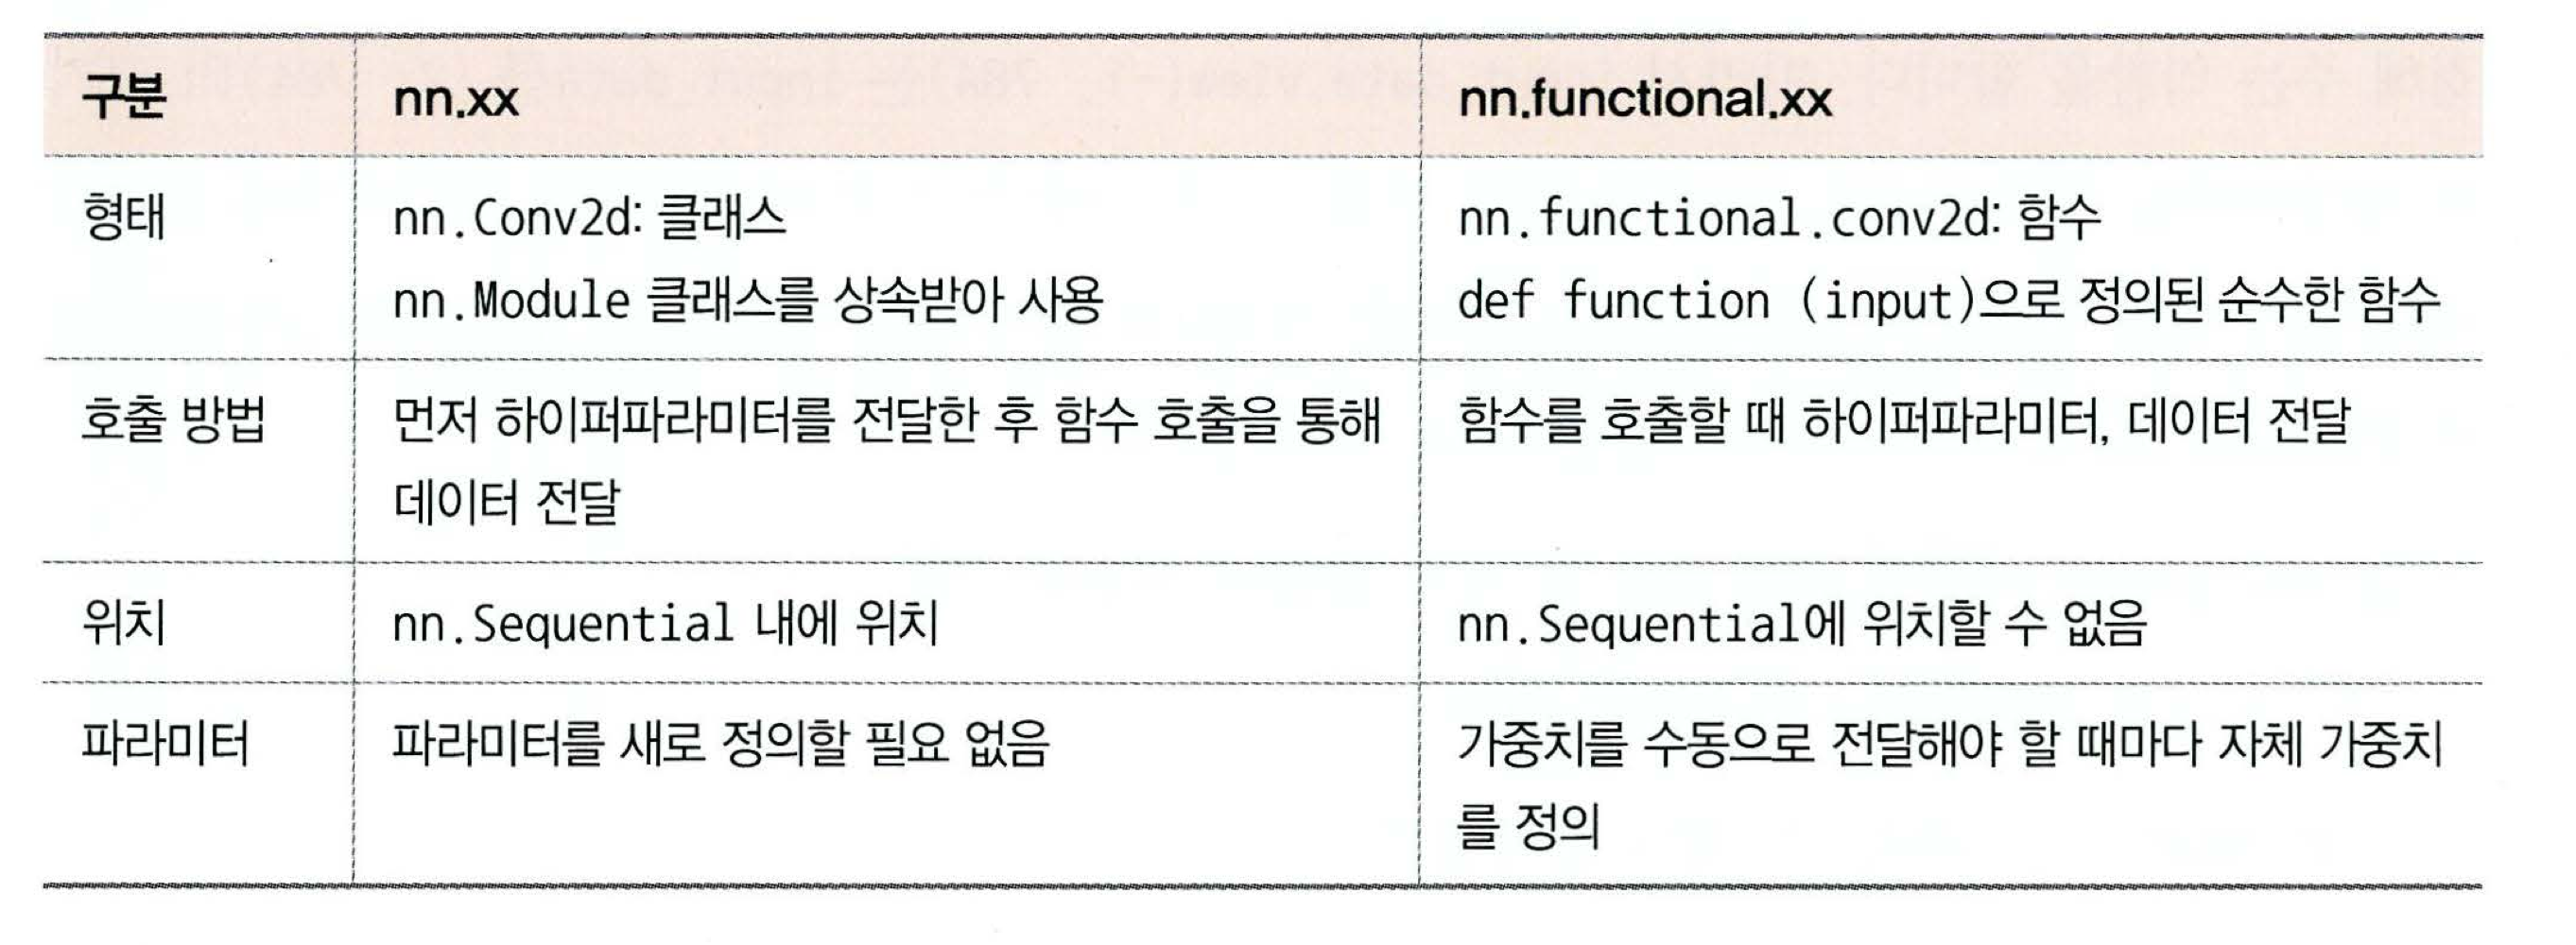

nn.Sequential: 계층을 차례로 쌓을 수 있도록 Wx+b와 같은 수식과 활성화 함수를 연결

nn.Conv2d()
- 주요 파라미터
    - in_channels: 입력 채널의 수
    - out_channels: 출력 채널의 수
    - kernel_size: 커널의 크기
    - padding: 패딩 크기
- 출력 크기 구하는 공식: (W - F + 2P) / S + 1

BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화

MaxPool2d: 이미지 크기를 축소시키는 용도로 사용
- 주요 파라미터
    - kernel_size: m x n 행렬로 구성된 가중치
    - stride: 입력 데이터에 커널을 적용할 때 이동할 간격
- 출력 크기 구하는 공식: IF / F

**코드 필사**

In [1]:
#라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
#CPU 혹은 GPU 장치 확인
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
#fashion_mnist 데이터셋 내려받기
train_dataset=torchvision.datasets.FashionMNIST('./content', download=True,
                                                transform=transforms.Compose([transforms.ToTensor()]))
test_dataset=torchvision.datasets.FashionMNIST('./content', download=True,
                                                train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 333kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.53MB/s]


In [4]:
#fashion_mnist 데이터를 데이터로더에 전달
train_loader=torch.utils.data.DataLoader(train_dataset,
                                         batch_size=100)
test_loader=torch.utils.data.DataLoader(test_dataset,
                                        batch_size=100)

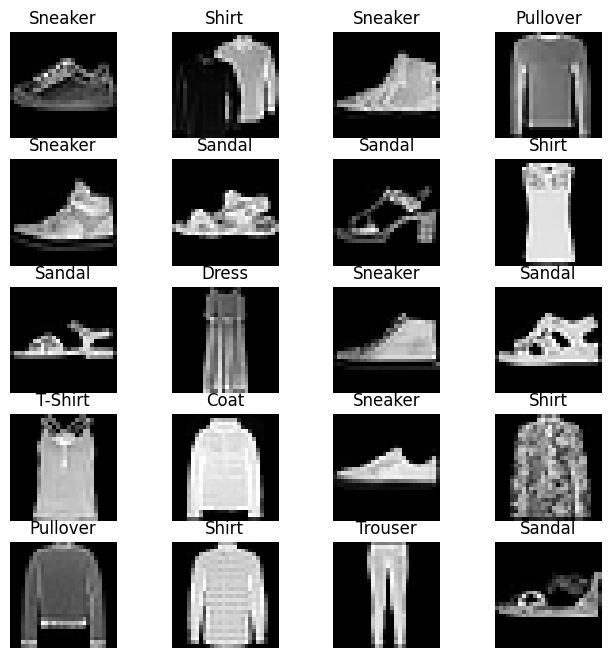

In [5]:
#분류에 사용될 클래스 정의
labels_map={0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
            5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'}

fig=plt.figure(figsize=(8,8))
columns=4
rows=5
for i in range(1, columns*rows+1):
    img_xy=np.random.randint(len(train_dataset))
    img=train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

In [6]:
#심층 신경망 모델 생성
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN, self).__init__()
        self.fc1=nn.Linear(in_features=784, out_features=256)
        self.drop=nn.Dropout(0.25)
        self.fc2=nn.Linear(in_features=256, out_features=128)
        self.fc3=nn.Linear(in_features=128, out_features=10)

    def forward(self, input_data):
        out=input_data.view(-1, 784)
        out=F.relu(self.fc1(out))
        out=self.drop(out)
        out=F.relu(self.fc2(out))
        out=self.fc3(out)
        return out

In [7]:
#심층 신경망에서 필요한 파라미터 정의
learning_rate=0.001
model=FashionDNN()
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
#심층 신경망을 이용한 모델 학습
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)

        train=Variable(images.view(100,1,28,28))
        labels=Variable(labels)

        outputs=model(train)
        loss=criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count % 50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels=images.to(device), labels.to(device)
                labels_list.append(labels)
                test=Variable(images.view(100,1,28,28))
                outputs=model(test)
                predictions=torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()
                total+=len(labels)

            accuracy=correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5880501866340637, Accuracy: 83.37999725341797%
Iteration: 1000, Loss: 0.4343370497226715, Accuracy: 84.72000122070312%
Iteration: 1500, Loss: 0.4130397140979767, Accuracy: 84.68000030517578%
Iteration: 2000, Loss: 0.338174432516098, Accuracy: 85.55000305175781%
Iteration: 2500, Loss: 0.3054232895374298, Accuracy: 85.94000244140625%
Iteration: 3000, Loss: 0.3173857033252716, Accuracy: 86.1500015258789%


In [9]:
#합성곱 네트워크 생성
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1=nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2=nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1=nn.Linear(in_features=64*6*6, out_features=600)
        self.drop=nn.Dropout2d(0.25)
        self.fc2=nn.Linear(in_features=600, out_features=120)
        self.fc3=nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out=self.layer1(x)
        out=self.layer2(out)
        out=out.view(out.size(0),-1)
        out=self.fc1(out)
        out=self.drop(out)
        out=self.fc2(out)
        out=self.fc3(out)
        return out

In [10]:
#합성곱 네트워크를 위한 파라미터 정의
learning_rate=0.001
model=FashionCNN()
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [11]:
#모델 학습 및 성능 평가
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)

        train=Variable(images.view(100,1,28,28))
        labels=Variable(labels)

        outputs=model(train)
        loss=criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count+=1

        if not (count % 50):
            total=0
            correct=0
            for images, labels in test_loader:
                images, labels=images.to(device), labels.to(device)
                labels_list.append(labels)
                test=Variable(images.view(100,1,28,28))
                outputs=model(test)
                predictions=torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct+= (predictions==labels).sum()
                total+=len(labels)

            accuracy=correct*100/total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.41751429438591003, Accuracy: 87.54000091552734%
Iteration: 1000, Loss: 0.31873053312301636, Accuracy: 87.55000305175781%
Iteration: 1500, Loss: 0.3221202790737152, Accuracy: 88.12999725341797%
Iteration: 2000, Loss: 0.2267911285161972, Accuracy: 89.2699966430664%
Iteration: 2500, Loss: 0.14879858493804932, Accuracy: 89.80999755859375%
Iteration: 3000, Loss: 0.17345933616161346, Accuracy: 91.0%
